# 03. 소방서 위치 정보 EDA

**대상 파일:**
- `소방청_전국소방서 좌표현황(XY좌표)_20240901.csv` — 전국 소방서/안전센터 좌표
- `서울시 소방서,안전센터,구조대 위치 정보.csv` — 서울 소방 기관 위치

**목표:** 소방 기관 분포 파악 및 지도 시각화

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('../data')
print('데이터 디렉토리:', DATA_DIR.resolve())

데이터 디렉토리: D:\DMU\빅데이터분석프로젝트\BigdataAnalysis-project\data


## 1. 전국 소방서 좌표 데이터 로드

In [2]:
df_station = pd.read_csv(
    DATA_DIR / '소방청_전국소방서 좌표현황(XY좌표)_20240901.csv',
    encoding='euc-kr'
)
print(f'행: {df_station.shape[0]:,} | 열: {df_station.shape[1]}')
df_station.head()

행: 1,216 | 열: 9


,번호,소방서 및 안전센터명,주소,상위 본부명,전화번호,X좌표,Y좌표,유형,등록일
0,1,수성소방서-수성-119 안전센터,대구광역시 수성구 들안로60길 30,대구소방안전본부,053-741-2119,35.856757,128.620850,119안전센터,2018-03-17
1,2,수성소방서-황금-119 안전센터,대구광역시 수성구 동대구로12길 41,대구소방안전본부,053-764-0119,35.835493,128.626425,119안전센터,2018-03-17
2,3,수성소방서-만촌-119 안전센터,대구광역시 수성구 달구벌대로 2658,대구소방안전본부,053-752-0119,35.855340,128.652108,119안전센터,2018-03-17
3,4,수성소방서-범물-119 안전센터,대구광역시 수성구 청호로 87,대구소방안전본부,053-780-5261,35.825528,128.644384,119안전센터,2018-03-17
4,5,북부소방서_대구-산격-119 안전센터,대구광역시 북구 유통단지로8길 88,대구소방안전본부,053-350-5790,35.906077,128.614247,119안전센터,2018-03-17


In [3]:
print('컬럼 목록:')
for col in df_station.columns:
    print(f'  {col}: {df_station[col].dtype}')

컬럼 목록:
  번호: int64
  소방서 및 안전센터명: object
  주소: object
  상위 본부명: object
  전화번호: object
  X좌표: float64
  Y좌표: float64
  유형: object
  등록일: object


In [4]:
print('결측값 현황:')
print(df_station.isnull().sum())

결측값 현황:
번호             0
소방서 및 안전센터명    0
주소             0
상위 본부명         0
전화번호           1
X좌표            0
Y좌표            0
유형             0
등록일            0
dtype: int64


## 2. 서울시 소방 기관 위치 데이터 로드

In [5]:
df_seoul = pd.read_csv(
    DATA_DIR / '서울시 소방서,안전센터,구조대 위치 정보.csv',
    encoding='utf-8-sig'
)
print(f'행: {df_seoul.shape[0]:,} | 열: {df_seoul.shape[1]}')
df_seoul.head(10)

행: 181 | 열: 9


,연번,서ㆍ센터ID,서ㆍ센터명,유형구분명,도서지역포함여부,상위서ㆍ센터ID,일련번호,X좌표,Y좌표
0,no,firstat_cnter_id,firstat_cnter_nm,type_div_nm,islnds_area_incls_yn,upper_firstat_cnter_id,sn,xcrdnt,ycrdnt
1,1,1100106,회현119안전센터,안전센터/구조대,,1100000,NaN,198522.99900000,550971.30300000
2,2,1100211,도봉산산악구조대,안전센터/구조대,,1100000,NaN,203074.04665600,565427.99142000
3,3,1100212,북한산산악구조대,안전센터/구조대,,1100000,NaN,194994.66571900,560097.88896300
4,4,1100213,관악산산악구조대,안전센터/구조대,,1100000,NaN,195129.59190000,539763.99600200
5,5,1100512,본부현장대응단,안전센터/구조대,,1100000,NaN,199028.50810000,551050.12310000
6,6,1102000,동작소방서,소방서,,1100000,NaN,192727.71200000,543911.47200000
7,7,1102101,동작119안전센터,안전센터/구조대,,1102000,NaN,192718.70500000,543910.48000000
8,8,1102102,노량진119안전센터,안전센터/구조대,,1102000,NaN,195310.03900000,546021.91400000
9,9,1102103,상도119안전센터,안전센터/구조대,,1102000,NaN,193774.33000000,544394.12500000


In [6]:
print('컬럼 목록:')
for col in df_seoul.columns:
    print(f'  {col}: {df_seoul[col].dtype}')

컬럼 목록:
  연번: object
  서ㆍ센터ID: object
  서ㆍ센터명: object
  유형구분명: object
  도서지역포함여부: object
  상위서ㆍ센터ID: object
  일련번호: object
  X좌표: object
  Y좌표: object


## 3. 전국 소방서 기본 분석

유형 관련 컬럼: ['유형']

유형 분포:
유형
119안전센터    1001
소방서         215
Name: count, dtype: int64


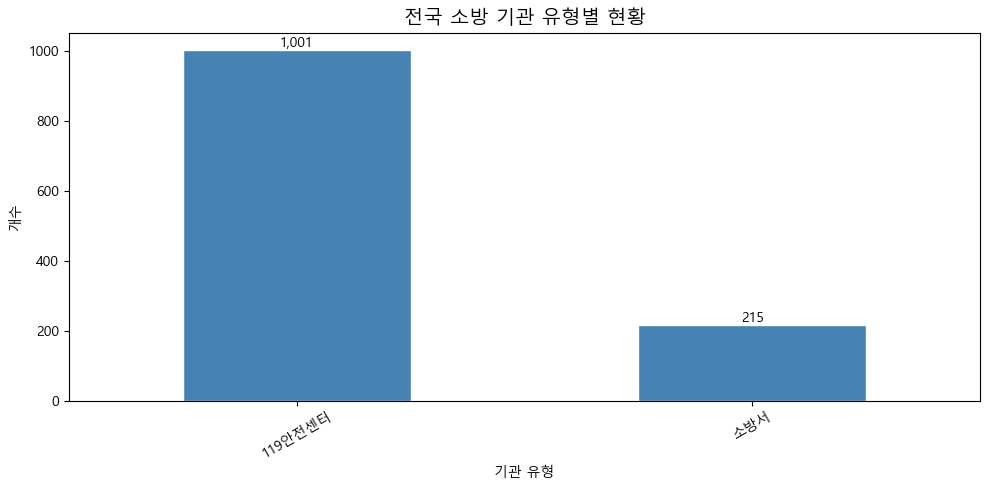

In [7]:
# 컬럼명 확인 후 유형 분류 컬럼 찾기
type_col = [c for c in df_station.columns if '유형' in str(c) or 'type' in str(c).lower()]
print('유형 관련 컬럼:', type_col)

if type_col:
    col = type_col[0]
    type_counts = df_station[col].value_counts()
    print(f'\n{col} 분포:')
    print(type_counts)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('전국 소방 기관 유형별 현황', fontsize=14)
    ax.set_xlabel('기관 유형')
    ax.set_ylabel('개수')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

## 4. 전국 소방서 지도 시각화

In [8]:
# 좌표 컬럼 확인
lat_col = [c for c in df_station.columns if 'Y' in str(c) or 'lat' in str(c).lower() or '위도' in str(c)]
lon_col = [c for c in df_station.columns if 'X' in str(c) or 'lon' in str(c).lower() or '경도' in str(c)]
print('위도 후보:', lat_col)
print('경도 후보:', lon_col)

위도 후보: ['Y좌표']
경도 후보: ['X좌표']


In [9]:
# 좌표가 있는 행만 사용
coord_df = df_station.copy()

# 수치형 좌표 컬럼 자동 탐지
numeric_cols = df_station.select_dtypes(include='number').columns.tolist()
print('수치형 컬럼:', numeric_cols)
print('각 컬럼 범위:')
for col in numeric_cols:
    print(f'  {col}: {df_station[col].min():.4f} ~ {df_station[col].max():.4f}')

수치형 컬럼: ['번호', 'X좌표', 'Y좌표']
각 컬럼 범위:
  번호: 1.0000 ~ 1216.0000
  X좌표: 33.2325 ~ 38.4410
  Y좌표: 124.7175 ~ 130.8982


In [10]:
# 위도(34~38), 경도(124~132) 범위로 좌표 컬럼 식별
lat_candidates = [c for c in df_station.select_dtypes(include='number').columns
                  if df_station[c].between(34, 39).mean() > 0.5]
lon_candidates = [c for c in df_station.select_dtypes(include='number').columns
                  if df_station[c].between(124, 132).mean() > 0.5]

print('위도 컬럼:', lat_candidates)
print('경도 컬럼:', lon_candidates)

if lat_candidates and lon_candidates:
    lat_c = lat_candidates[0]
    lon_c = lon_candidates[0]
    
    map_df = df_station[[lat_c, lon_c]].dropna()
    
    m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='CartoDB positron')
    
    name_col = [c for c in df_station.columns if '명' in str(c) or 'nm' in str(c).lower()]
    
    for _, row in df_station.dropna(subset=[lat_c, lon_c]).iterrows():
        popup_text = str(row[name_col[0]]) if name_col else '소방서'
        folium.CircleMarker(
            location=[row[lat_c], row[lon_c]],
            radius=3,
            color='red',
            fill=True,
            fill_color='orange',
            fill_opacity=0.7,
            popup=popup_text
        ).add_to(m)
    
    print(f'지도에 표시된 소방 기관 수: {len(map_df):,}')
    display(m)
else:
    print('좌표 컬럼을 자동으로 찾을 수 없습니다. 위 컬럼 목록을 참고해 수동 지정 필요.')

위도 컬럼: ['X좌표']
경도 컬럼: ['Y좌표']
지도에 표시된 소방 기관 수: 1,216


## 5. 서울 소방 기관 분석

In [11]:
print('서울시 소방 기관 데이터 기본 정보:')
print(df_seoul.info())
print('\n상위 10행:')
df_seoul.head(10)

서울시 소방 기관 데이터 기본 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   연번        181 non-null    object
 1   서ㆍ센터ID    181 non-null    object
 2   서ㆍ센터명     181 non-null    object
 3   유형구분명     181 non-null    object
 4   도서지역포함여부  181 non-null    object
 5   상위서ㆍ센터ID  181 non-null    object
 6   일련번호      1 non-null      object
 7   X좌표       181 non-null    object
 8   Y좌표       181 non-null    object
dtypes: object(9)
memory usage: 12.9+ KB
None

상위 10행:


,연번,서ㆍ센터ID,서ㆍ센터명,유형구분명,도서지역포함여부,상위서ㆍ센터ID,일련번호,X좌표,Y좌표
0,no,firstat_cnter_id,firstat_cnter_nm,type_div_nm,islnds_area_incls_yn,upper_firstat_cnter_id,sn,xcrdnt,ycrdnt
1,1,1100106,회현119안전센터,안전센터/구조대,,1100000,NaN,198522.99900000,550971.30300000
2,2,1100211,도봉산산악구조대,안전센터/구조대,,1100000,NaN,203074.04665600,565427.99142000
3,3,1100212,북한산산악구조대,안전센터/구조대,,1100000,NaN,194994.66571900,560097.88896300
4,4,1100213,관악산산악구조대,안전센터/구조대,,1100000,NaN,195129.59190000,539763.99600200
5,5,1100512,본부현장대응단,안전센터/구조대,,1100000,NaN,199028.50810000,551050.12310000
6,6,1102000,동작소방서,소방서,,1100000,NaN,192727.71200000,543911.47200000
7,7,1102101,동작119안전센터,안전센터/구조대,,1102000,NaN,192718.70500000,543910.48000000
8,8,1102102,노량진119안전센터,안전센터/구조대,,1102000,NaN,195310.03900000,546021.91400000
9,9,1102103,상도119안전센터,안전센터/구조대,,1102000,NaN,193774.33000000,544394.12500000


In [12]:
# 각 컬럼 unique 값 확인
for col in df_seoul.columns:
    unique_vals = df_seoul[col].nunique()
    if unique_vals <= 20:
        print(f'{col} ({unique_vals}개): {df_seoul[col].unique()}')
    else:
        print(f'{col}: {unique_vals}개 고유값')

연번: 181개 고유값
서ㆍ센터ID: 181개 고유값
서ㆍ센터명: 158개 고유값
유형구분명 (3개): ['type_div_nm' '안전센터/구조대' '소방서']
도서지역포함여부 (2개): ['islnds_area_incls_yn' ' ']
상위서ㆍ센터ID: 28개 고유값
일련번호 (1개): ['sn' nan]
X좌표: 170개 고유값
Y좌표: 174개 고유값


## 6. 전국 소방서 좌표 산점도

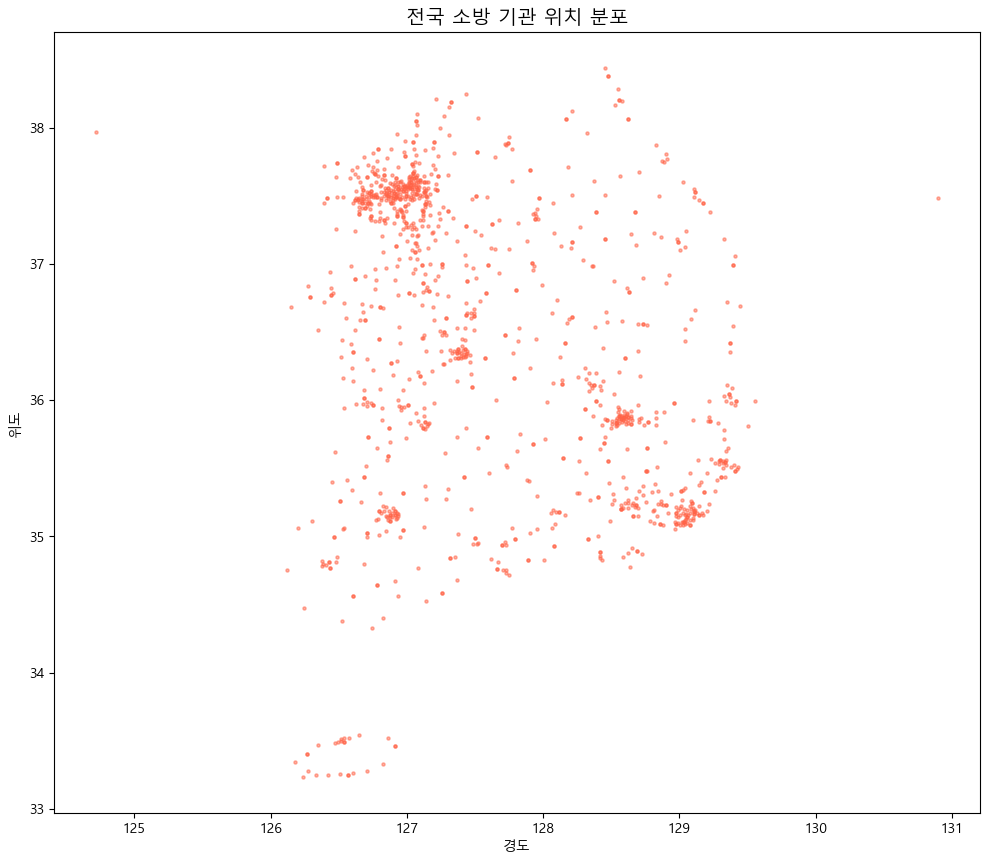

In [13]:
if lat_candidates and lon_candidates:
    lat_c = lat_candidates[0]
    lon_c = lon_candidates[0]
    
    plot_df = df_station.dropna(subset=[lat_c, lon_c])
    
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.scatter(plot_df[lon_c], plot_df[lat_c], s=5, alpha=0.5, color='tomato')
    ax.set_title('전국 소방 기관 위치 분포', fontsize=14)
    ax.set_xlabel('경도')
    ax.set_ylabel('위도')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

## 7. 요약 통계

In [14]:
print('=== 전국 소방서 좌표 데이터 요약 ===')
print(f'  총 기관 수: {len(df_station):,}개')
print(f'  결측 좌표: {df_station[numeric_cols].isnull().any(axis=1).sum():,}개')

print('\n=== 서울시 소방 기관 데이터 요약 ===')
print(f'  총 기관 수: {len(df_seoul):,}개')

=== 전국 소방서 좌표 데이터 요약 ===
  총 기관 수: 1,216개
  결측 좌표: 0개

=== 서울시 소방 기관 데이터 요약 ===
  총 기관 수: 181개
